In [39]:
import pandas as pd
pd.read_excel 
import nltk
nltk.download('punkt')

[nltk_data] Downloading package punkt to
[nltk_data]     /Users/yigitkinali/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [47]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from scipy.sparse import hstack, csr_matrix
import nltk
from nltk.tokenize import word_tokenize
from sklearn.feature_extraction.text import CountVectorizer


# Dosya yolunu belirle
file_path = "./processed_datasets/imdb_with_platforms.csv"  # Eğer masaüstündeki Project klasöründeyse: "Desktop/Project/imdb_with_platforms.csv"

# Veriyi oku
imdb = pd.read_csv(file_path)

# İlk 5 satırı göster
imdb.head()

,duration,description,year,type,title,votes,genre,rating,platform,platform_flag,...,genre_romance,genre_music,genre_horror,genre_gameshow,genre_western,genre_biography,genre_comedy,genre_adult,genre_action,genre_drama
0,70,true story of notorious australian outlaw ned ...,1906,0,the story of the kelly gang,537,biography crime drama,6.1,np,0,...,0,0,0,0,0,1,0,0,0,1
1,53,two men of high rank are both wooing the beaut...,1911,0,den sorte drøm,171,drama,5.9,np,0,...,0,0,0,0,0,0,0,0,0,1
2,100,the fabled queen of egypts affair with roman g...,1912,0,cleopatra,420,drama history,5.2,np,0,...,0,0,0,0,0,0,0,0,0,1
3,68,loosely adapted from dantes divine comedy and ...,1911,0,linferno,2019,adventure drama fantasy,7.0,np,0,...,0,0,0,0,0,0,0,0,0,1
4,60,an account of the life of jesus christ based o...,1912,0,from the manger to the cross or jesus of nazareth,438,biography drama,5.7,np,0,...,0,0,0,0,0,1,0,0,0,1


Accuracy: 0.8744871424443802

Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.92      0.93     14878
           1       0.55      0.61      0.58      2427

    accuracy                           0.87     17305
   macro avg       0.74      0.76      0.75     17305
weighted avg       0.88      0.87      0.88     17305

Confusion Matrix:
 [[13662  1216]
 [  956  1471]]


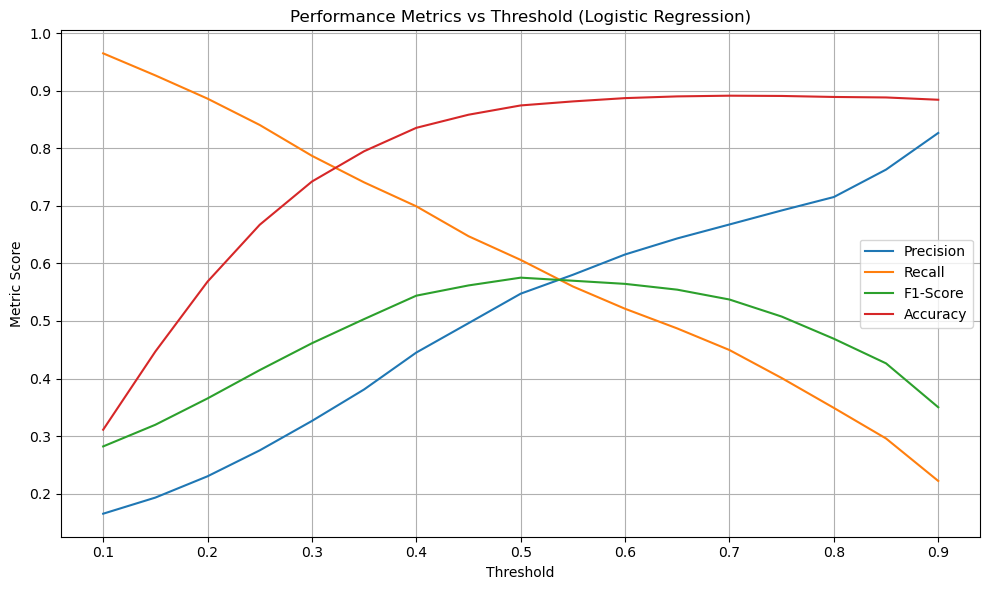


[Threshold = 0.35]
Accuracy: 0.7949147645189252
Precision: 0.3810936837643069
Recall: 0.7408323032550473
F1 Score: 0.5032890132960112
Confusion Matrix:
 [[11958  2920]
 [  629  1798]]


In [69]:
# 2. Hedef değişken
y = imdb["platform_flag"]

# 3. Metin özelliği (TF-IDF uygulanacak)
X_text_raw = imdb["description"].fillna("")

# 4. Sayısal özellikler
X_numeric = imdb[["duration", "year", "votes", "rating"]].fillna(0)

# 5. Kategorik özellikler (genre, type, title)
X_categorical = imdb[["type", "title", "genre"]].fillna("unknown")

# 6. Genre binary flag sütunları
genre_columns = [col for col in imdb.columns if col.startswith("genre_")]
X_genres = imdb[genre_columns].fillna(0)

# 7. TF-IDF (description)
tfidf = TfidfVectorizer(max_features=5000, stop_words="english")
X_text = tfidf.fit_transform(X_text_raw)

# 8. Sayısal veriyi standardize et
scaler = StandardScaler()
X_numeric_scaled = scaler.fit_transform(X_numeric)

# 9. Kategorik veriyi one-hot encode et
encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=True)
X_categorical_encoded = encoder.fit_transform(X_categorical)

# 10. Tüm özellikleri birleştir
X_full = hstack([
    X_text,                            # TF-IDF description
    csr_matrix(X_numeric_scaled),      # duration, year, votes, rating
    X_categorical_encoded,             # one-hot type, title, genre
    csr_matrix(X_genres.values)        # genre flags (binary)
])

# 11. Eğitim/test ayrımı
X_train, X_test, y_train, y_test = train_test_split(
    X_full, y, test_size=0.2, random_state=42, stratify=y
)

# 12. Logistic Regression modeli
model = LogisticRegression(max_iter=1000 , class_weight = 'balanced')
model.fit(X_train, y_train)

# Varsayılan threshold ile tahmin
y_pred = model.predict(X_test)

# Performans metrikleri
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
import matplotlib.pyplot as plt
from sklearn.metrics import precision_score, recall_score, f1_score

# Olasılıklar (class 1 için)
y_proba = model.predict_proba(X_test)[:, 1]

# Threshold değerleri
thresholds = np.arange(0.1, 0.91, 0.05)

# Metrik listeleri
precisions = []
recalls = []
f1_scores = []
accuracies = []

# Her threshold için skorları hesapla
for thresh in thresholds:
    y_pred_thresh = (y_proba >= thresh).astype(int)
    precisions.append(precision_score(y_test, y_pred_thresh))
    recalls.append(recall_score(y_test, y_pred_thresh))
    f1_scores.append(f1_score(y_test, y_pred_thresh))
    accuracies.append(accuracy_score(y_test, y_pred_thresh))

# Çizim
plt.figure(figsize=(10, 6))
plt.plot(thresholds, precisions, label="Precision")
plt.plot(thresholds, recalls, label="Recall")
plt.plot(thresholds, f1_scores, label="F1-Score")
plt.plot(thresholds, accuracies, label="Accuracy")
plt.xlabel("Threshold")
plt.ylabel("Metric Score")
plt.title("Performance Metrics vs Threshold (Logistic Regression)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Generalizes better
# Manuel threshold değeri 
custom_threshold = 0.35
y_pred_manual = (y_proba >= custom_threshold).astype(int)

# Raporlama
print(f"\n[Threshold = {custom_threshold}]")
print("Accuracy:", accuracy_score(y_test, y_pred_manual))
print("Precision:", precision_score(y_test, y_pred_manual))
print("Recall:", recall_score(y_test, y_pred_manual))
print("F1 Score:", f1_score(y_test, y_pred_manual))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_manual))

In [ ]:
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from scipy.sparse import hstack, csr_matrix
import pandas as pd

# 1. Veriyi oku
imdb = pd.read_csv("imdb_with_platforms.csv")

# 2. Hedef değişken
y = imdb["platform_flag"]

# 3. Metin (description)
X_text_raw = imdb["description"].fillna("")

# 4. Sayısal özellikler
X_numeric = imdb[["duration", "year", "votes", "rating"]].fillna(0)

# 5. Kategorik özellikler
X_categorical = imdb[["type", "title", "genre"]].fillna("unknown")

# 6. Genre binary flag sütunları
genre_columns = [col for col in imdb.columns if col.startswith("genre_")]
X_genres = imdb[genre_columns].fillna(0)

# 7. TF-IDF vektörleştirme
tfidf = TfidfVectorizer(max_features=5000, stop_words="english")
X_text = tfidf.fit_transform(X_text_raw)

# 8. Sayısal verileri ölçekleme
scaler = StandardScaler()
X_numeric_scaled = scaler.fit_transform(X_numeric)

# 9. Kategorik verileri one-hot encode et
encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=True)
X_categorical_encoded = encoder.fit_transform(X_categorical)

# 10. Özellikleri birleştir
X_full = hstack([
    X_text,                             # TF-IDF: description
    csr_matrix(X_numeric_scaled),       # duration, year, votes, rating
    X_categorical_encoded,              # one-hot: type, title, genre
    csr_matrix(X_genres.values)         # genre_* binary flags
])

# 11. Eğitim / test ayrımı
X_train, X_test, y_train, y_test = train_test_split(
    X_full, y, test_size=0.2, random_state=42, stratify=y
)

# 12. SVM modeli (threshold yok)
svm_model = SVC(
    kernel="linear",
    C=1.0,
    class_weight="balanced",
    random_state=42
)

# 13. Modeli eğit
svm_model.fit(X_train, y_train)

# 14. Tahmin yap
y_pred = svm_model.predict(X_test)

# 15. Performans raporu
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))